# **IMDB BERT Embeddings: Pipeline 2 — Advanced Embeddings (Deep Learning)**

This notebook implements transformer-based embeddings using **BERT** with three distinct strategies:

1. **Frozen BERT — CLS Token**: Extract the `[CLS]` token from a frozen BERT encoder, then train a head classifier (Logistic Regression / SVM).
2. **Frozen BERT — Mean Pooling**: Extract mean-pooled token embeddings from a frozen BERT encoder, then train a head classifier.
3. **Fine-tuned BERT**: End-to-end fine-tuning of BERT with a classification head using PyTorch.

**Key distinction:**
- Frozen strategies: BERT weights are **never updated**. Only the downstream classifier learns.
- Fine-tuning: All BERT weights (plus the classifier head) are updated via backpropagation.

Results and confusion matrices are exported for comparison across pipelines.

## **1. Import Libraries**

In [2]:
import os
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## **2. Load Dataset**


In [3]:
DATA_DIR = r"C:\Users\Ale\Documents\Final_NLP\Homework_2\Text-Representation-and-Basic-Text-Mining\Text_Classification_and_Embeddings\Models\Data\preprocessed_data\pipeline_2"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val   = pd.read_csv(os.path.join(DATA_DIR, "validation.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print("Train shape    :", train.shape)
print("Validation shape:", val.shape)
print("Test shape     :", test.shape)
train.head(3)

Train shape    : (20000, 2)
Validation shape: (2500, 2)
Test shape     : (2500, 2)


,text,label
0,always huge james bond fanatic seen almost fil...,1
1,christian say movie terrible acting unreal sit...,0
2,neatly sandwiched stranger small film noir pic...,1


In [4]:
X_train, y_train = train["text"], train["label"]
X_val,   y_val   = val["text"],   val["label"]
X_test,  y_test  = test["text"],  test["label"]

---
## **3. Shared Utilities**
### 3.1 Confusion Matrix

In [5]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name: str,
    pipeline_name: str,
    representation_name: str,
    output_dir: str = "results_bert",
) -> None:
    """
    Plots and saves a confusion matrix as a PNG file inside
    `<output_dir>/conf_matrix/`.

    Parameters
    ----------
    y_true              : Ground-truth labels.
    y_pred              : Predicted labels.
    model_name          : Classifier name (e.g. 'LogisticRegression').
    pipeline_name       : Pipeline identifier (e.g. 'pipeline_2').
    representation_name : Embedding strategy (e.g. 'BERT_CLS_Frozen').
    output_dir          : Root directory for saving outputs.
    """
    conf_matrix_dir = os.path.join(output_dir, "conf_matrix")
    os.makedirs(conf_matrix_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} | {pipeline_name} | {representation_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    file_name = (
        f"{model_name}_{pipeline_name}_{representation_name}_confusion_matrix.png"
    )
    save_path = os.path.join(conf_matrix_dir, file_name)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {save_path}")

### 3.2 Save Results to CSV

In [6]:
def save_results(
    metrics: dict,
    model_name: str,
    pipeline_name: str,
    representation_name: str,
    output_dir: str = "results_bert",
    results_file: str = "experiment_results.csv",
) -> None:
    """
    Appends experiment metrics to a cumulative CSV file.

    Parameters
    ----------
    metrics              : Dictionary of metric name -> value.
    model_name           : Classifier name.
    pipeline_name        : Pipeline identifier.
    representation_name  : Embedding strategy.
    output_dir           : Root directory for saving outputs.
    results_file         : CSV filename inside `output_dir`.
    """
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, results_file)

    row = {
        "Model": model_name,
        "Pipeline": pipeline_name,
        "Representation": representation_name,
        **metrics,
    }
    current_df = pd.DataFrame([row])

    if os.path.exists(save_path):
        existing = pd.read_csv(save_path)
        updated  = pd.concat([existing, current_df], ignore_index=True)
    else:
        updated = current_df

    updated.to_csv(save_path, index=False)
    print(f"Results appended to: {save_path}")

### 3.3 Evaluation Helper (sklearn classifiers)

In [7]:
def compute_metrics(model, X_test, y_test) -> tuple:
    """
    Evaluates a scikit-learn classifier and measures inference time.

    Returns
    -------
    metrics     : dict with Accuracy, Precision, Recall, F1-Score, timing.
    predictions : numpy array of predicted labels.
    """
    start       = time.time()
    predictions = model.predict(X_test)
    elapsed     = time.time() - start

    metrics = {
        "Accuracy":                          accuracy_score(y_test,  predictions),
        "Precision":                         precision_score(y_test, predictions, average="binary"),
        "Recall":                            recall_score(y_test,    predictions, average="binary"),
        "F1-Score":                          f1_score(y_test,        predictions, average="binary"),
        "Inference_Time_Seconds":            elapsed,
        "Average_Inference_Time_Per_Sample": elapsed / len(y_test),
    }
    return metrics, predictions

---
# **Part A — Frozen BERT (Feature Extraction)**

BERT weights are **completely frozen** (`torch.no_grad()` + explicit `requires_grad=False`).  
We extract sentence vectors once and train classical classifiers on top.

Two pooling strategies are compared:
- **CLS token** — the `[CLS]` hidden state at position 0.
- **Mean pooling** — masked average of all token hidden states (padding excluded).

## **4. Frozen BERT Embedding Extraction**

In [8]:
def compute_frozen_bert_embeddings(
    X_train,
    X_val,
    X_test,
    model_name: str = "bert-base-uncased",
    pooling: str = "cls",       # "cls" or "mean"
    max_length: int = 256,
    batch_size: int = 16,
):
    """
    Extracts sentence embeddings from a **frozen** BERT encoder.

    BERT is placed in eval() mode and all parameter gradients are disabled,
    so no weight update can happen regardless of calling code.

    Parameters
    ----------
    X_train, X_val, X_test : Text series / arrays.
    model_name             : HuggingFace model identifier.
    pooling                : 'cls'  -> [CLS] hidden state (position 0).
                             'mean' -> masked mean of all token states.
    max_length             : Maximum token sequence length.
    batch_size             : Texts per forward pass.

    Returns
    -------
    X_train_emb, X_val_emb, X_test_emb : numpy arrays of shape (N, 768).
    """
    assert pooling in ("cls", "mean"), "pooling must be 'cls' or 'mean'"

    tokenizer  = BertTokenizer.from_pretrained(model_name)
    bert_model = BertModel.from_pretrained(model_name)

    # Freeze ALL parameters — weights will never be updated
    for param in bert_model.parameters():
        param.requires_grad = False

    bert_model.eval()
    bert_model.to(DEVICE)
    print(f"[Frozen BERT | pooling={pooling}] Model loaded on {DEVICE}")

    def _extract(texts):
        embeddings = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = list(texts[i : i + batch_size])
                encoded = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                )
                input_ids      = encoded["input_ids"].to(DEVICE)
                attention_mask = encoded["attention_mask"].to(DEVICE)

                outputs     = bert_model(input_ids=input_ids, attention_mask=attention_mask)
                last_hidden = outputs.last_hidden_state  # (B, T, 768)

                if pooling == "cls":
                    # [CLS] is always the first token
                    batch_emb = last_hidden[:, 0, :]                           # (B, 768)
                else:
                    # Mean pooling — exclude padding with attention_mask
                    mask_exp  = attention_mask.unsqueeze(-1).float()           # (B, T, 1)
                    sum_emb   = (last_hidden * mask_exp).sum(dim=1)            # (B, 768)
                    token_cnt = mask_exp.sum(dim=1).clamp(min=1e-9)            # (B, 1)
                    batch_emb = sum_emb / token_cnt                            # (B, 768)

                embeddings.extend(batch_emb.cpu().numpy())
        return np.array(embeddings)

    print("  Extracting training embeddings ...")
    X_train_emb = _extract(X_train)
    print("  Extracting validation embeddings ...")
    X_val_emb   = _extract(X_val)
    print("  Extracting test embeddings ...")
    X_test_emb  = _extract(X_test)

    print(f"  Shapes — train: {X_train_emb.shape}, val: {X_val_emb.shape}, test: {X_test_emb.shape}")
    return X_train_emb, X_val_emb, X_test_emb

## **5. Frozen BERT — CLS Token**

In [ ]:
X_train_cls, X_val_cls, X_test_cls = compute_frozen_bert_embeddings(
    X_train, X_val, X_test, pooling="cls"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3011.19it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Frozen BERT | pooling=cls] Model loaded on cuda
  Extracting training embeddings ...


### 5.1 Logistic Regression on CLS Embeddings

In [ ]:
lr_cls = LogisticRegression(max_iter=1000, random_state=SEED)
lr_cls.fit(X_train_cls, y_train)

lr_cls_metrics, lr_cls_preds = compute_metrics(lr_cls, X_test_cls, y_test)
print("Logistic Regression | CLS Frozen")
print(classification_report(y_test, lr_cls_preds))

Logistic Regression | CLS Frozen
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1250
           1       0.82      0.81      0.81      1250

    accuracy                           0.81      2500
   macro avg       0.81      0.81      0.81      2500
weighted avg       0.81      0.81      0.81      2500



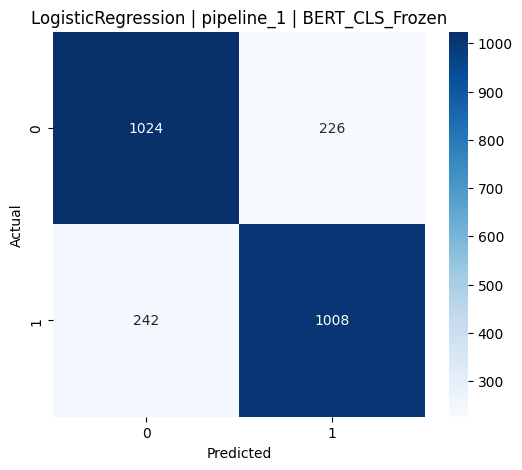

Confusion matrix saved to: results_bert\conf_matrix\LogisticRegression_pipeline_1_BERT_CLS_Frozen_confusion_matrix.png
Results appended to: results_bert\experiment_results.csv


In [ ]:
plot_confusion_matrix(
    y_true=y_test, y_pred=lr_cls_preds,
    model_name="LogisticRegression",
    pipeline_name="pipeline_2",
    representation_name="BERT_CLS_Frozen",
)

save_results(
    metrics=lr_cls_metrics,
    model_name="LogisticRegression",
    pipeline_name="pipeline_2",
    representation_name="BERT_CLS_Frozen",
)

### 5.2 SVM on CLS Embeddings

In [ ]:
svm_cls = LinearSVC(random_state=SEED)
svm_cls.fit(X_train_cls, y_train)

svm_cls_metrics, svm_cls_preds = compute_metrics(svm_cls, X_test_cls, y_test)
print("SVM | CLS Frozen")
print(classification_report(y_test, svm_cls_preds))

SVM | CLS Frozen
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1250
           1       0.82      0.81      0.81      1250

    accuracy                           0.81      2500
   macro avg       0.81      0.81      0.81      2500
weighted avg       0.81      0.81      0.81      2500



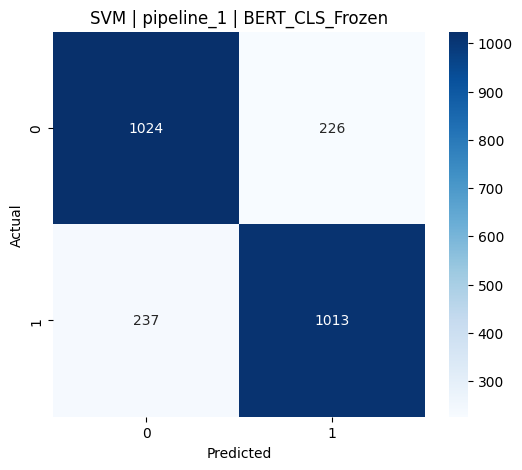

Confusion matrix saved to: results_bert\conf_matrix\SVM_pipeline_1_BERT_CLS_Frozen_confusion_matrix.png
Results appended to: results_bert\experiment_results.csv


In [ ]:
plot_confusion_matrix(
    y_true=y_test, y_pred=svm_cls_preds,
    model_name="SVM",
    pipeline_name="pipeline_2",
    representation_name="BERT_CLS_Frozen",
)

save_results(
    metrics=svm_cls_metrics,
    model_name="SVM",
    pipeline_name="pipeline_2",
    representation_name="BERT_CLS_Frozen",
)

## **6. Frozen BERT — Mean Pooling**

In [ ]:
X_train_mean, X_val_mean, X_test_mean = compute_frozen_bert_embeddings(
    X_train, X_val, X_test, pooling="mean"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9366.91it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Frozen BERT | pooling=mean] Model loaded on cuda
  Extracting training embeddings ...
  Extracting validation embeddings ...
  Extracting test embeddings ...
  Shapes — train: (20000, 768), val: (2500, 768), test: (2500, 768)


### 6.1 Logistic Regression on Mean Pooling Embeddings

In [ ]:
lr_mean = LogisticRegression(max_iter=1000, random_state=SEED)
lr_mean.fit(X_train_mean, y_train)

lr_mean_metrics, lr_mean_preds = compute_metrics(lr_mean, X_test_mean, y_test)
print("Logistic Regression | Mean Pooling Frozen")
print(classification_report(y_test, lr_mean_preds))

Logistic Regression | Mean Pooling Frozen
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1250
           1       0.85      0.85      0.85      1250

    accuracy                           0.85      2500
   macro avg       0.85      0.85      0.85      2500
weighted avg       0.85      0.85      0.85      2500



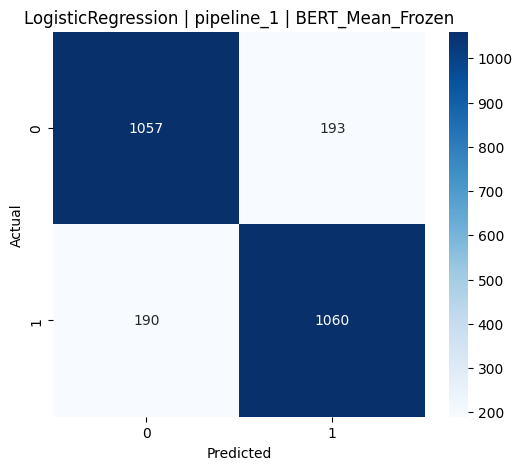

Confusion matrix saved to: results_bert\conf_matrix\LogisticRegression_pipeline_1_BERT_Mean_Frozen_confusion_matrix.png
Results appended to: results_bert\experiment_results.csv


In [ ]:
plot_confusion_matrix(
    y_true=y_test, y_pred=lr_mean_preds,
    model_name="LogisticRegression",
    pipeline_name="pipeline_2",
    representation_name="BERT_Mean_Frozen",
)

save_results(
    metrics=lr_mean_metrics,
    model_name="LogisticRegression",
    pipeline_name="pipeline_2",
    representation_name="BERT_Mean_Frozen",
)

### 6.2 SVM on Mean Pooling Embeddings

In [ ]:
svm_mean = LinearSVC(random_state=SEED)
svm_mean.fit(X_train_mean, y_train)

svm_mean_metrics, svm_mean_preds = compute_metrics(svm_mean, X_test_mean, y_test)
print("SVM | Mean Pooling Frozen")
print(classification_report(y_test, svm_mean_preds))

SVM | Mean Pooling Frozen
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1250
           1       0.84      0.84      0.84      1250

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500



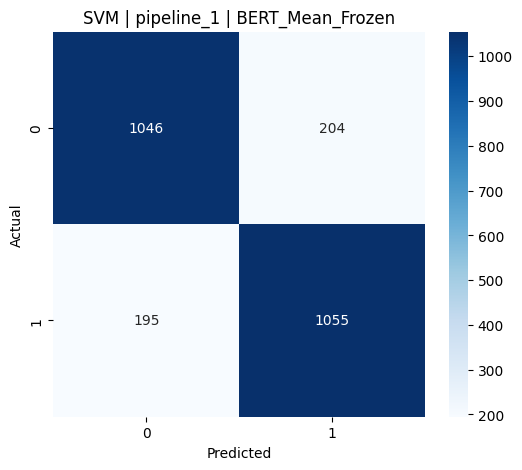

Confusion matrix saved to: results_bert\conf_matrix\SVM_pipeline_1_BERT_Mean_Frozen_confusion_matrix.png
Results appended to: results_bert\experiment_results.csv


In [ ]:
plot_confusion_matrix(
    y_true=y_test, y_pred=svm_mean_preds,
    model_name="SVM",
    pipeline_name="pipeline_2",
    representation_name="BERT_Mean_Frozen",
)

save_results(
    metrics=svm_mean_metrics,
    model_name="SVM",
    pipeline_name="pipeline_2",
    representation_name="BERT_Mean_Frozen",
)

---
# **Part B — Fine-Tuned BERT (End-to-End Training)**

Here we fine-tune **all** BERT weights together with a classification head.  
This is a completely separate approach from Part A — the model is in `train()` mode
and AdamW updates every parameter on every step.

```
Text
→ BertForSequenceClassification
    ├─ BERT encoder  (weights updated via backprop)
    └─ Linear head   (2 output logits)
→ Cross-Entropy Loss
→ AdamW + linear LR schedule with warmup
```

## **7. Dataset and DataLoader**

In [ ]:
class IMDBDataset(Dataset):
    """
    PyTorch Dataset that tokenizes texts on-the-fly.

    Parameters
    ----------
    texts      : Iterable of raw text strings.
    labels     : Iterable of integer labels (0 or 1).
    tokenizer  : HuggingFace tokenizer.
    max_length : Maximum token length (with truncation).
    """

    def __init__(self, texts, labels, tokenizer, max_length: int = 256):
        self.texts      = list(texts)
        self.labels     = list(labels)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

## **8. Fine-Tuning Configuration**

In [ ]:
# ─── Hyperparameters ─────────────────────────────────────────────────────────
FT_MODEL_NAME = "bert-base-uncased"
FT_MAX_LENGTH = 256
FT_BATCH_SIZE = 16
FT_EPOCHS     = 3
FT_LR         = 2e-5
FT_WARMUP     = 0.1    # fraction of total steps for warmup
NUM_LABELS    = 2
# ─────────────────────────────────────────────────────────────────────────────

ft_tokenizer = BertTokenizer.from_pretrained(FT_MODEL_NAME)

train_dataset = IMDBDataset(X_train, y_train, ft_tokenizer, FT_MAX_LENGTH)
val_dataset   = IMDBDataset(X_val,   y_val,   ft_tokenizer, FT_MAX_LENGTH)
test_dataset  = IMDBDataset(X_test,  y_test,  ft_tokenizer, FT_MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=FT_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=FT_BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=FT_BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 1250 | Val: 157 | Test: 157


## **9. Model, Optimizer and Scheduler**

In [ ]:
ft_model = BertForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,
    num_labels=NUM_LABELS,
)
ft_model.to(DEVICE)

optimizer = AdamW(ft_model.parameters(), lr=FT_LR)

total_steps  = len(train_loader) * FT_EPOCHS
warmup_steps = int(FT_WARMUP * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps} | Warmup steps: {warmup_steps}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10482.73it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Total training steps: 3750 | Warmup steps: 375


## **10. Training and Validation Loop**

In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
    """One full training epoch. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_epoch(model, loader):
    """Evaluates the model; returns (mean_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = outputs.logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc   = 0.0
best_ckpt_path = "results_bert/best_finetuned_bert.pt"
os.makedirs("results_bert", exist_ok=True)

for epoch in range(1, FT_EPOCHS + 1):
    t_loss, t_acc = train_epoch(ft_model, train_loader, optimizer, scheduler)
    v_loss, v_acc = evaluate_epoch(ft_model, val_loader)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    print(
        f"Epoch {epoch}/{FT_EPOCHS}  "
        f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  "
        f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}"
    )

    # Checkpoint the best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(ft_model.state_dict(), best_ckpt_path)
        print(f"  -> New best model saved (val_acc={v_acc:.4f})")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/3  Train Loss: 0.3711  Train Acc: 0.8354  Val Loss: 0.2762  Val Acc: 0.8928
  -> New best model saved (val_acc=0.8928)
Epoch 2/3  Train Loss: 0.2148  Train Acc: 0.9253  Val Loss: 0.2500  Val Acc: 0.9084
  -> New best model saved (val_acc=0.9084)
Epoch 3/3  Train Loss: 0.1261  Train Acc: 0.9654  Val Loss: 0.3546  Val Acc: 0.9124
  -> New best model saved (val_acc=0.9124)

Training complete. Best val accuracy: 0.9124


### Learning Curves

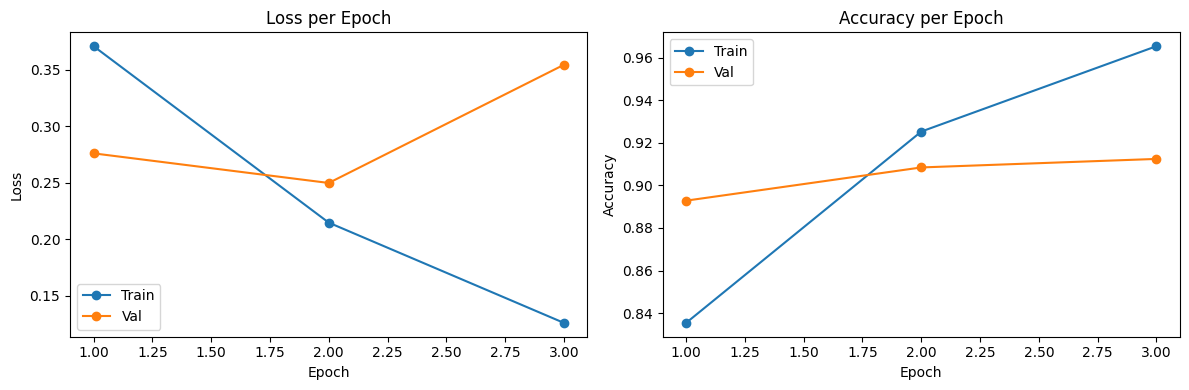

Learning curves saved to: results_bert/finetuned_bert_learning_curves.png


In [ ]:
epochs_range = range(1, FT_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train", marker="o")
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   marker="o")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
curves_path = "results_bert/finetuned_bert_learning_curves.png"
plt.savefig(curves_path, bbox_inches="tight")
plt.show()
print(f"Learning curves saved to: {curves_path}")

## **11. Test Evaluation — Fine-Tuned BERT**

In [ ]:
def predict_finetuned(model, loader):
    """
    Runs inference with the fine-tuned model.

    Returns
    -------
    all_preds  : numpy array of predicted labels.
    all_labels : numpy array of ground-truth labels.
    elapsed    : Total inference time in seconds.
    """
    model.eval()
    all_preds, all_labels = [], []

    start = time.time()
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=-1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    elapsed = time.time() - start
    return np.array(all_preds), np.array(all_labels), elapsed

In [ ]:
# Load best checkpoint before evaluating on test set
ft_model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
print(f"Best checkpoint loaded from: {best_ckpt_path}")

ft_preds, ft_labels, ft_elapsed = predict_finetuned(ft_model, test_loader)

ft_metrics = {
    "Accuracy":                          accuracy_score(ft_labels,  ft_preds),
    "Precision":                         precision_score(ft_labels, ft_preds, average="binary"),
    "Recall":                            recall_score(ft_labels,    ft_preds, average="binary"),
    "F1-Score":                          f1_score(ft_labels,        ft_preds, average="binary"),
    "Inference_Time_Seconds":            ft_elapsed,
    "Average_Inference_Time_Per_Sample": ft_elapsed / len(ft_labels),
}

print("\nFine-Tuned BERT — Test Metrics")
for k, v in ft_metrics.items():
    print(f"  {k}: {v:.6f}")

print("\nClassification Report:")
print(classification_report(ft_labels, ft_preds))

C:\Users\Ale\AppData\Local\Temp\ipykernel_24804\1551503084.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ft_model.load_state_dict(torch.load(best_ckpt_path, map_locati

Best checkpoint loaded from: results_bert/best_finetuned_bert.pt

Fine-Tuned BERT — Test Metrics
  Accuracy: 0.916400
  Precision: 0.905058
  Recall: 0.930400
  F1-Score: 0.917554
  Inference_Time_Seconds: 26.138097
  Average_Inference_Time_Per_Sample: 0.010455

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1250
           1       0.91      0.93      0.92      1250

    accuracy                           0.92      2500
   macro avg       0.92      0.92      0.92      2500
weighted avg       0.92      0.92      0.92      2500



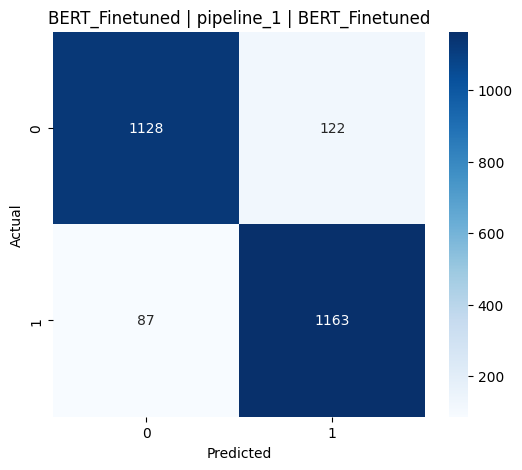

Confusion matrix saved to: results_bert\conf_matrix\BERT_Finetuned_pipeline_1_BERT_Finetuned_confusion_matrix.png
Results appended to: results_bert\experiment_results.csv


In [ ]:
plot_confusion_matrix(
    y_true=ft_labels, y_pred=ft_preds,
    model_name="BERT_Finetuned",
    pipeline_name="pipeline_2",
    representation_name="BERT_Finetuned",
)

save_results(
    metrics=ft_metrics,
    model_name="BERT_Finetuned",
    pipeline_name="pipeline_2",
    representation_name="BERT_Finetuned",
)

---
## **12. Summary Comparison**

In [ ]:
results_path = "results_bert/experiment_results.csv"
summary = pd.read_csv(results_path)

display_cols = ["Model", "Representation", "Accuracy", "Precision", "Recall", "F1-Score"]
print(summary[display_cols].to_string(index=False))

             Model   Representation  Accuracy  Precision  Recall  F1-Score
LogisticRegression  BERT_CLS_Frozen    0.8128   0.816856  0.8064  0.811594
               SVM  BERT_CLS_Frozen    0.8148   0.817595  0.8104  0.813982
LogisticRegression BERT_Mean_Frozen    0.8468   0.845970  0.8480  0.846984
               SVM BERT_Mean_Frozen    0.8404   0.837967  0.8440  0.840972
    BERT_Finetuned   BERT_Finetuned    0.9164   0.905058  0.9304  0.917554


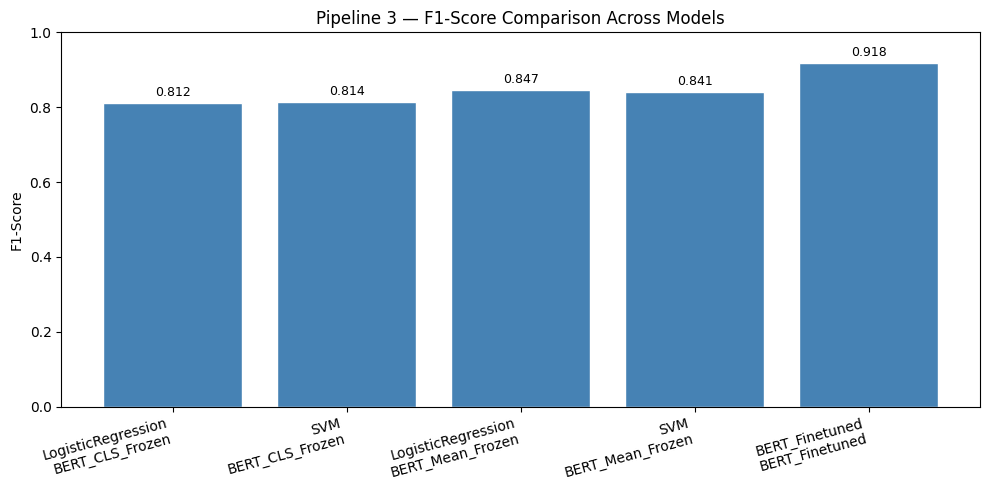

Comparison chart saved to: results_bert/pipeline_1_f1_comparison.png


In [ ]:
# Bar chart — F1-Score by model and representation
summary["Label"] = summary["Model"] + "\n" + summary["Representation"]

plt.figure(figsize=(10, 5))
bars = plt.bar(summary["Label"], summary["F1-Score"], color="steelblue", edgecolor="white")
plt.ylim(0, 1)
plt.ylabel("F1-Score")
plt.title("Pipeline 3 — F1-Score Comparison Across Models")
plt.xticks(rotation=15, ha="right")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
chart_path = "results_bert/pipeline_2_f1_comparison.png"
plt.savefig(chart_path, bbox_inches="tight")
plt.show()
print(f"Comparison chart saved to: {chart_path}")